# *Laboratório III (n2) - Processamento Digital de Imagens - Prof. Dr. Cassio Vinhal*

Pedro Cézar S. Ferreira -  202302579 - Eng. de Computação

# Operadores de Segunda Ordem: LoG, DoG e Algoritmo de Marr-Hildreth

### Roteiro

- **Atividade 1** — Laplaciano para Aguçamento de Imagens
- **Atividade 2** — Detecção de Bordas por Operadores de Segunda Ordem
  - **Entregável 1** — Imagem Sintética
  - **Entregável 2** — Resposta com Máscara M de Gonzalez & Woods (5×5)
  - **Entregável 3** — Resposta com Máscara −M
  - **Entregável 4** — Mapas de Cruzamentos por Zero (M e −M)
  - **Entregável 5** — LoG Amostrado e DoG (razões 1,6:1 e 1,75:1)
  - **Entregável 6** — Resultados para Filtros 5×5 e 11×11
  - **Entregável 7** — Marr-Hildreth pela Rota de Dois Passos
  - **Entregável 8** — Comparação: Dois Passos vs LoG Direto
  - **Entregável 9** — Discussão Crítica


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi
from scipy.ndimage import convolve

# Função utilitária de visualização
def show_images(images, titles, cmap='gray', cols=2, figsize=(15, 10)):
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(images[i], cmap=cmap)
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Cruzamentos por Zero
def cruzamentos_por_zero(img_filtrada, limiar=0):
    # Localiza cruzamentos por zero: para cada pixel, avalia 4 pares de vizinhos opostos
    # (vertical, horizontal, 2 diagonais) numa vizinhança 3x3. Se os sinais de um par
    # forem opostos e |p1-p2| > limiar, marca borda.
    linhas, colunas = img_filtrada.shape
    bordas = np.zeros((linhas, colunas), dtype=np.uint8)
    for i in range(1, linhas - 1):
        for j in range(1, colunas - 1):
            pares = [
                (img_filtrada[i-1, j],   img_filtrada[i+1, j]),
                (img_filtrada[i, j-1],   img_filtrada[i, j+1]),
                (img_filtrada[i-1, j-1], img_filtrada[i+1, j+1]),
                (img_filtrada[i-1, j+1], img_filtrada[i+1, j-1])
            ]
            for p1, p2 in pares:
                if (p1 * p2 <= 0) and abs(p1 - p2) > limiar:
                    bordas[i, j] = 255
                    break
    return bordas

# LoG: Laplaciano da Gaussiana por amostragem — Eq. (7)/(8) do roteiro
def LoG(k, s):
    n = 2 * k + 1
    filtro = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r2 = (i - k)**2 + (j - k)**2
            filtro[i, j] = -(1 - r2 / (2. * s**2)) * np.exp(-r2 / (2. * s**2)) / (pi * s**4)
    filtro = filtro - np.mean(filtro)  # Impor soma nula
    filtro = np.round(filtro / np.sqrt((filtro**2).sum()), 3)
    return filtro

# DoG: Diferença de Gaussianas — Eq. (9) do roteiro
def DOG(k, s1, s2):
    n = 2 * k + 1
    filtro = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r2 = (i - k)**2 + (j - k)**2
            filtro[i, j] = (
                np.exp(-r2 / (2. * s1**2)) / (2 * pi * s1**2)
                - np.exp(-r2 / (2. * s2**2)) / (2 * pi * s2**2)
            )
    filtro = np.round(filtro / np.sqrt((filtro**2).sum()), 3)
    return filtro

# Gaussiana passa-baixa (soma unitária) — Passo 1 de Marr-Hildreth
def gaussiana(k, s):
    n = 2 * k + 1
    filtro = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r2 = (i - k)**2 + (j - k)**2
            filtro[i, j] = np.exp(-r2 / (2. * s**2)) / (2 * pi * s**2)
    filtro = filtro / filtro.sum()
    return filtro

# Algoritmo de Marr-Hildreth — rota de dois passos
def marr_hildreth(img, k, s, limiar=0):
    g = gaussiana(k, s)
    suave = convolve(img.astype(float), g, mode='nearest')
    L = np.array([[0,  1, 0],
                  [1, -4, 1],
                  [0,  1, 0]], dtype=float)
    resp = convolve(suave, L, mode='nearest')
    bordas = cruzamentos_por_zero(resp, limiar)
    return resp, bordas

# Sigma equivalente LoG <-> DoG — Equação (10) do roteiro
def sigma_equivalente(s1, s2):
    return np.sqrt((s1**2 * s2**2) / (s1**2 - s2**2) * np.log(s1**2 / s2**2))


## Atividade 1: Laplaciano para Aguçamento de Imagens

O operador Laplaciano é uma derivada de segunda ordem isotrópica que detecta variações rápidas de intensidade. Aplicado a uma imagem borrada, permite o aguçamento ao subtrair (ou somar, dependendo da convenção de sinal da máscara) a resposta laplaciana da imagem original. Abaixo, reproduzimos o procedimento das Figs. 3.38(a)–(e) de Gonzalez & Woods.


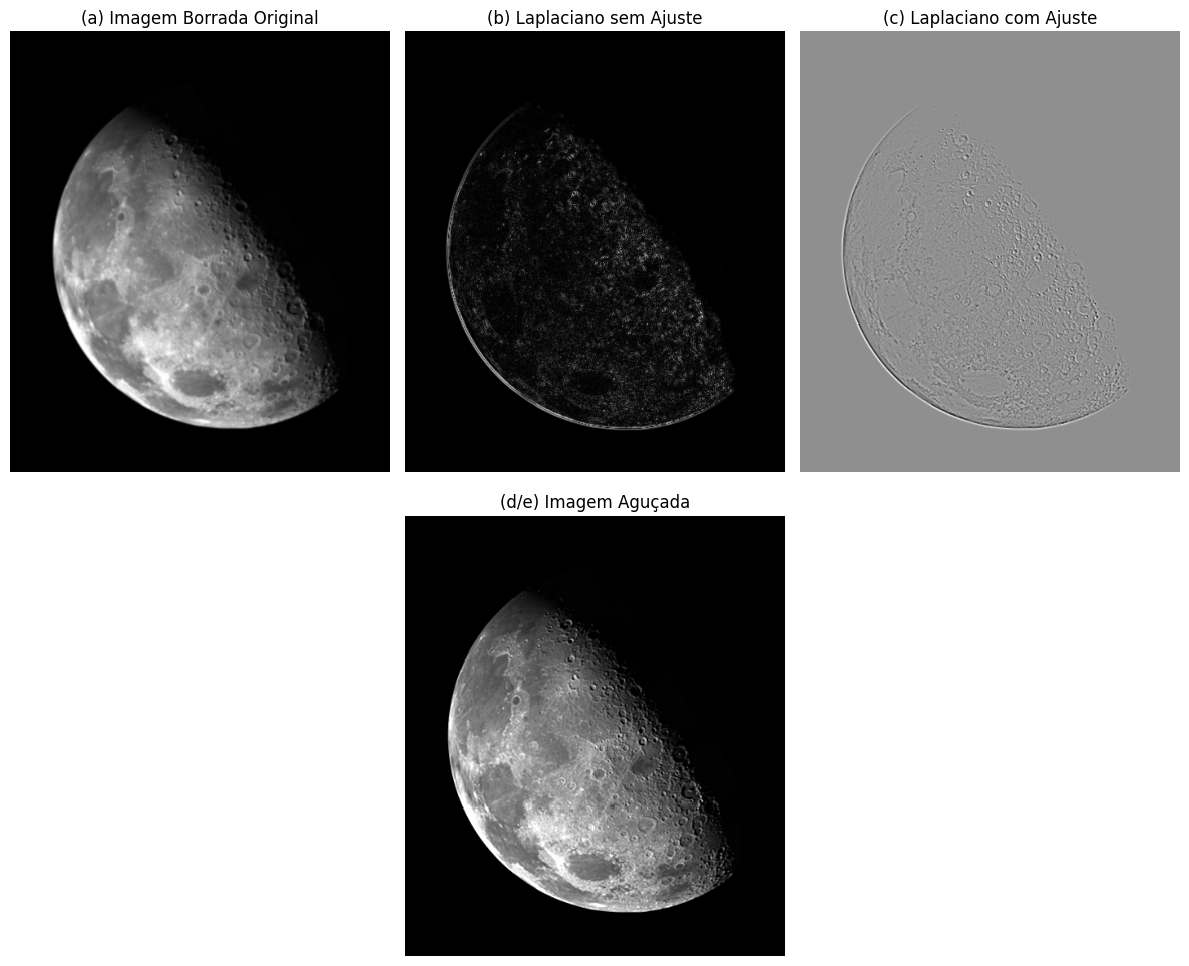

In [ ]:
# Carregar a imagem em escala de cinza (Fig 3.38(a))
img = cv2.imread('blurry_moon.tif', cv2.IMREAD_GRAYSCALE)


# Laplaciano em ponto flutuante (preserva valores negativos)
laplacian_raw = cv2.Laplacian(img, cv2.CV_64F)

# Fig 3.38(b): Laplaciano sem ajuste de escala
laplacian_no_scaling = np.uint8(np.absolute(laplacian_raw))

# Fig 3.38(c): Laplaciano com ajuste (mapeado para [0, 255])
laplacian_scaled = cv2.normalize(laplacian_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Fig 3.38(d/e): Aguçamento — subtrai o Laplaciano (centro negativo -4)
sharpened = np.clip(img - laplacian_raw, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('(a) Imagem Borrada Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(laplacian_no_scaling, cmap='gray')
plt.title('(b) Laplaciano sem Ajuste')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(laplacian_scaled, cmap='gray')
plt.title('(c) Laplaciano com Ajuste')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(sharpened, cmap='gray')
plt.title('(d/e) Imagem Aguçada')
plt.axis('off')

plt.tight_layout()
plt.show()


## Atividade 2: Detecção de Bordas por Operadores de Segunda Ordem

Nesta atividade, exploramos operadores de segunda ordem para detecção de bordas: a máscara compacta de Gonzalez & Woods, o Laplaciano da Gaussiana (LoG) amostrado, a Diferença de Gaussianas (DoG) e o algoritmo de Marr-Hildreth. A detecção de bordas é realizada pela localização dos **cruzamentos por zero** nas respostas filtradas. Os resultados são apresentados nos Entregáveis 1–9 a seguir.


### Entregável 1 — Imagem Sintética

Imagem sintética com fundo preto, um quadrado claro e um círculo claro, usada como base para todos os experimentos desta atividade.


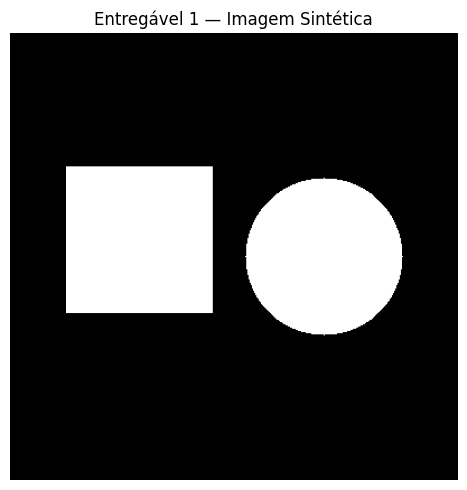

In [7]:
img_size = 400
synthetic_img = np.zeros((img_size, img_size), dtype=np.float32)
cv2.rectangle(synthetic_img, (50, 120), (180, 250), 255, -1)  # Quadrado
cv2.circle(synthetic_img, (280, 200), 70, 255, -1)            # Círculo

plt.figure(figsize=(5, 5))
plt.imshow(synthetic_img, cmap='gray')
plt.title('Entregável 1 — Imagem Sintética')
plt.axis('off')
plt.tight_layout()
plt.show()


### Entregável 2 — Resposta com Máscara M de Gonzalez & Woods (5×5)

Aplicamos a máscara $M$ 5×5 de Gonzalez & Woods (aproximação LoG compacta de soma nula) à imagem sintética e exibimos a resposta filtrada.


Máscara M de Gonzalez & Woods (5×5):
[[ 0.  0. -1.  0.  0.]
 [ 0. -1. -2. -1.  0.]
 [-1. -2. 16. -2. -1.]
 [ 0. -1. -2. -1.  0.]
 [ 0.  0. -1.  0.  0.]]

Soma dos coeficientes: 0.0


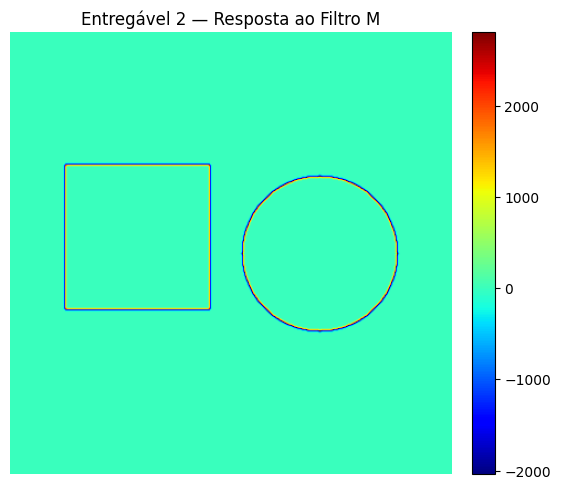

In [8]:
M = np.array([
    [ 0,  0, -1,  0,  0],
    [ 0, -1, -2, -1,  0],
    [-1, -2, 16, -2, -1],
    [ 0, -1, -2, -1,  0],
    [ 0,  0, -1,  0,  0]
], dtype=np.float32)

print('Máscara M de Gonzalez & Woods (5×5):')
print(M)
print(f'\nSoma dos coeficientes: {np.sum(M)}')

res_M = cv2.filter2D(synthetic_img, cv2.CV_32F, M)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(res_M, cmap='jet')
ax.set_title('Entregável 2 — Resposta ao Filtro M')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.axis('off')
plt.tight_layout()
plt.show()


### Entregável 3 — Resposta com Máscara −M

Aplicamos a versão negativa $-M$ à mesma imagem. A resposta é o simétrico da anterior; os cruzamentos por zero (Entregável 4) devem ser geometricamente idênticos.


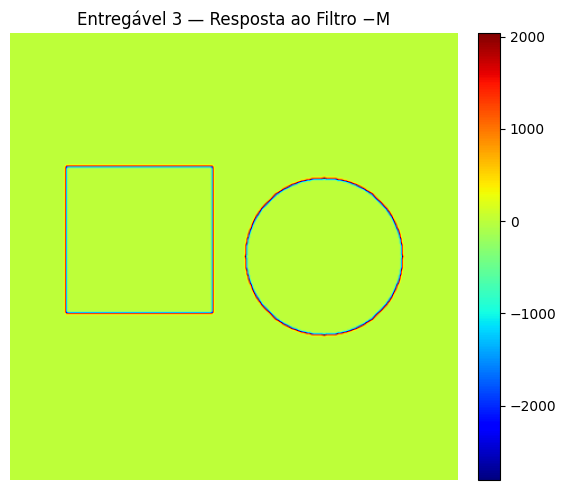

In [9]:
M_neg = -M

res_M_neg = cv2.filter2D(synthetic_img, cv2.CV_32F, M_neg)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(res_M_neg, cmap='jet')
ax.set_title('Entregável 3 — Resposta ao Filtro −M')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.axis('off')
plt.tight_layout()
plt.show()


### Entregável 4 — Mapas de Cruzamentos por Zero (M e −M)

Localizamos os cruzamentos por zero nas respostas de $M$ e $-M$. A inversão de sinal não deve alterar a posição das bordas detectadas.


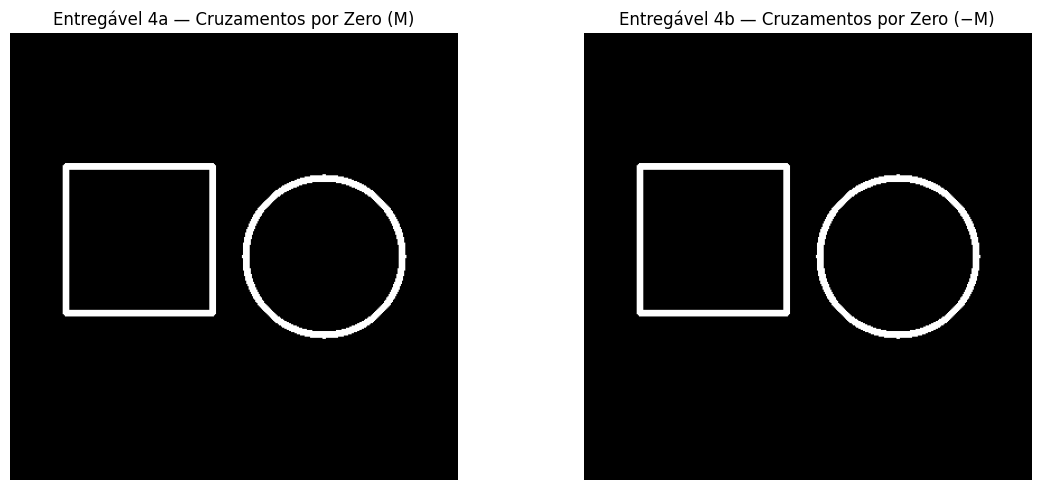

Diferença entre bordas M e −M: 0 pixels
A inversão de sinal preserva perfeitamente os cruzamentos por zero.


In [10]:
zc_M = cruzamentos_por_zero(res_M)
zc_M_neg = cruzamentos_por_zero(res_M_neg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(zc_M, cmap='gray')
axes[0].set_title('Entregável 4a — Cruzamentos por Zero (M)')
axes[0].axis('off')
axes[1].imshow(zc_M_neg, cmap='gray')
axes[1].set_title('Entregável 4b — Cruzamentos por Zero (−M)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

diff_bordas = np.sum(np.abs(zc_M.astype(int) - zc_M_neg.astype(int)))
print(f'Diferença entre bordas M e −M: {diff_bordas} pixels')
if diff_bordas == 0:
    print('A inversão de sinal preserva perfeitamente os cruzamentos por zero.')


#### Discussão — Convenção de Sinal e Máscara de Gonzalez & Woods

**A inversão de sinal preserva os cruzamentos por zero?**  
Sim. A máscara $M$ possui soma nula ($\sum M_{ij} = 0$), comportando-se como um operador derivativo puro. Ao multiplicar $M$ por $-1$, obtemos $-M$: a resposta filtrada $R_{-M} = -R_M$ simplesmente inverte o sinal de todos os valores. Como os cruzamentos por zero dependem apenas de **onde** o sinal muda (e não de **qual** sinal é positivo ou negativo), a geometria das bordas é identicamente preservada.

**A máscara de Gonzalez & Woods é uma amostragem direta da LoG contínua?**  
Não exatamente. A máscara $M$ é uma **aproximação discreta compacta** ajustada para uso prático em suporte 5×5. Seus coeficientes inteiros (centro $+16$, vizinhos $-2$, $-1$) não correspondem a uma amostragem direta de $\nabla^2 G(x,y)$ para um $\sigma$ específico, mas capturam o comportamento qualitativo do LoG: centro de sinal oposto ao anel circundante, com soma total nula — propriedade essencial de qualquer operador de segunda derivada.


### Entregável 5 — LoG Amostrado e DoG (razões 1,6:1 e 1,75:1)

Fixamos $\sigma_2 = 1{,}0$ e testamos as razões $\sigma_1:\sigma_2 = 1{,}6:1$ e $1{,}75:1$. Para cada razão, calculamos o $\sigma$ equivalente da LoG pela Equação (10) do roteiro:

$$\sigma^2 = \frac{\sigma_1^2 \, \sigma_2^2}{\sigma_1^2 - \sigma_2^2} \ln\!\left(\frac{\sigma_1^2}{\sigma_2^2}\right)$$

Em seguida, aplicamos o LoG amostrado (com $\sigma$ equivalente) e a DoG à imagem sintética e comparamos os cruzamentos por zero. Os filtros usam suporte 5×5 ($k=2$).


Razão 1.6:1  -> sigma1=1.60, sigma2=1.00, sigma_eq(LoG) = 1.2420
Razão 1.75:1 -> sigma1=1.75, sigma2=1.00, sigma_eq(LoG) = 1.2891


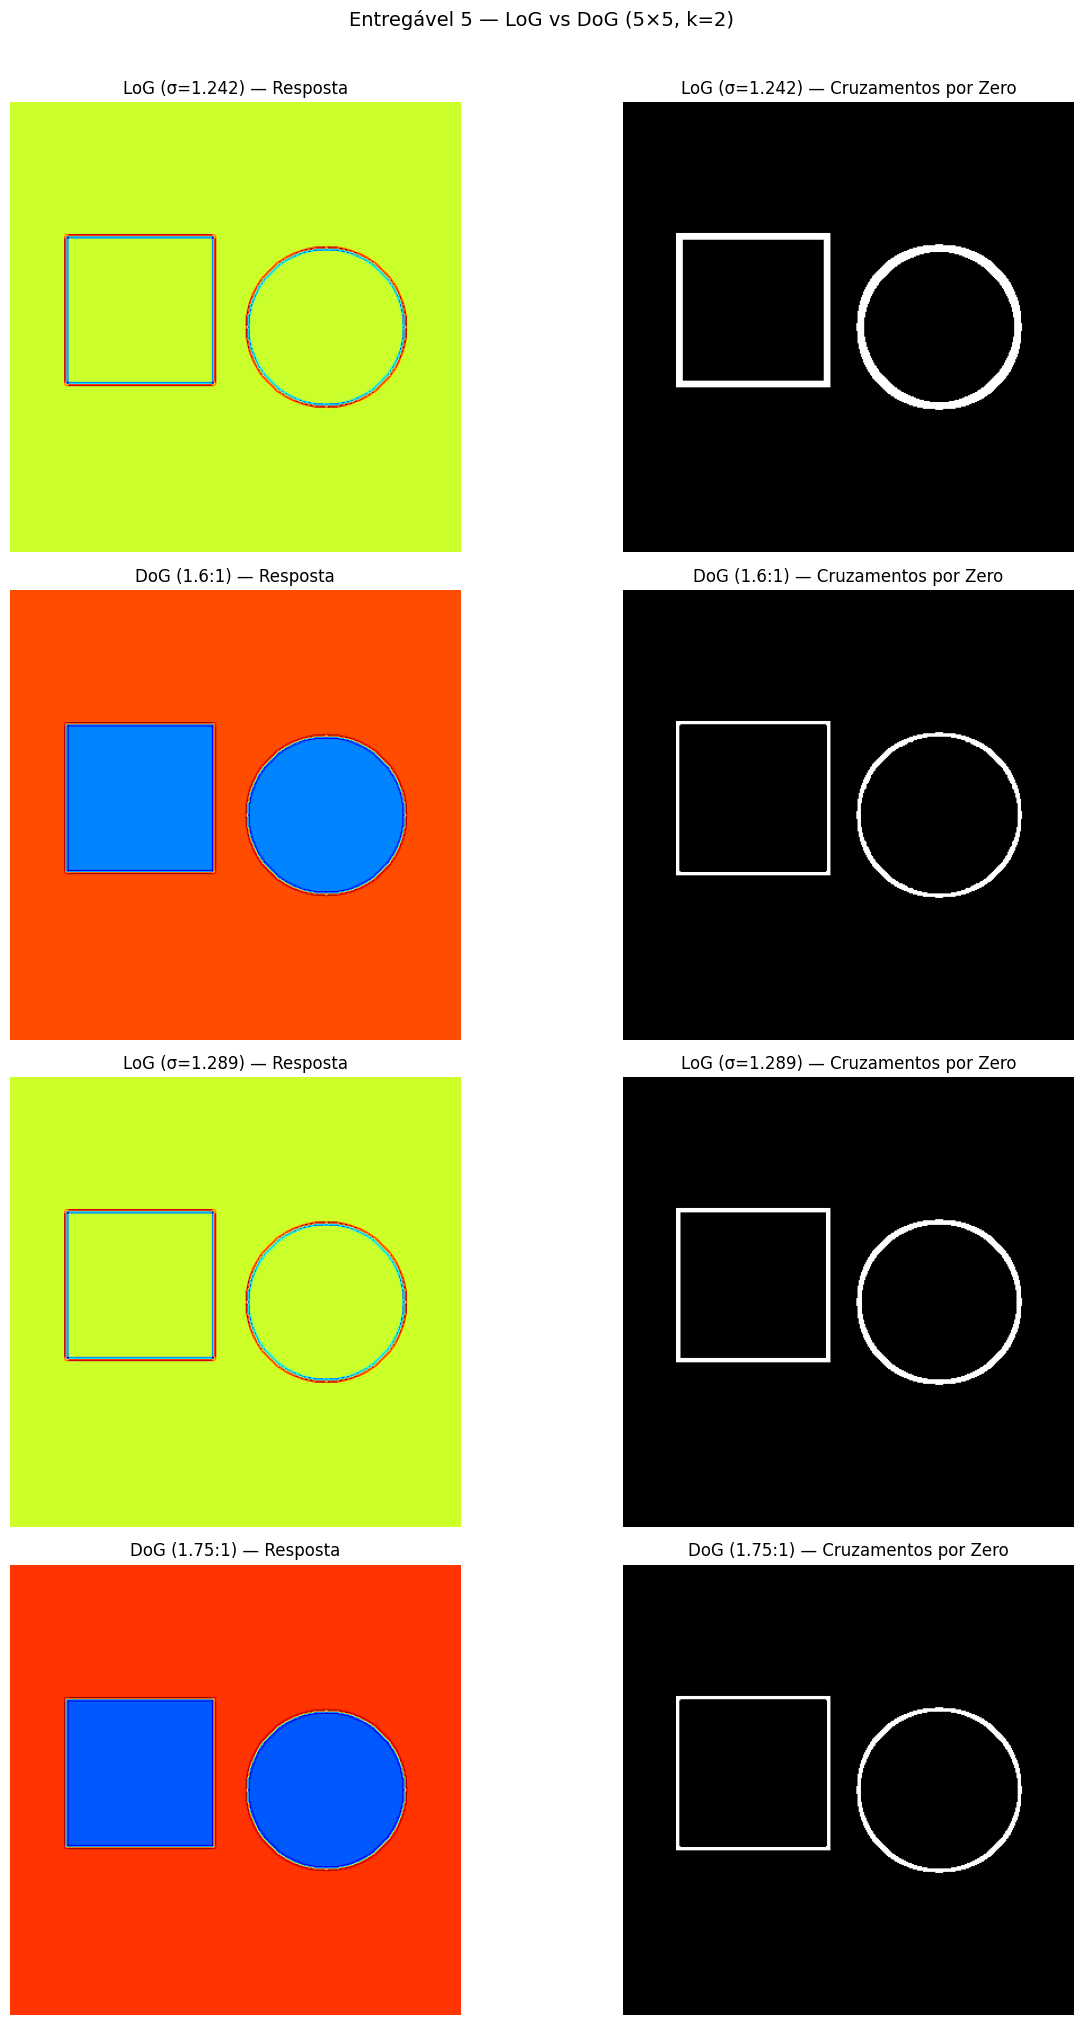


--- Coincidência dos Cruzamentos por Zero ---
  Razão 1.6:1: bordas LoG=6508, bordas DoG=3540, coincidentes=3540
  Razão 1.75:1: bordas LoG=4412, bordas DoG=3508, coincidentes=3508


In [11]:
k = 2   # Suporte 5x5
s2 = 1.0

# ===== Razão 1.6:1 =====
s1_16 = 1.6 * s2
sigma_eq_16 = sigma_equivalente(s1_16, s2)
print(f'Razão 1.6:1  -> sigma1={s1_16:.2f}, sigma2={s2:.2f}, sigma_eq(LoG) = {sigma_eq_16:.4f}')

log_16  = LoG(k, sigma_eq_16)
dog_16  = DOG(k, s1_16, s2)
res_log_16  = cv2.filter2D(synthetic_img, cv2.CV_32F, log_16)
res_dog_16  = cv2.filter2D(synthetic_img, cv2.CV_32F, dog_16)
zc_log_16   = cruzamentos_por_zero(res_log_16)
zc_dog_16   = cruzamentos_por_zero(res_dog_16)

# ===== Razão 1.75:1 =====
s1_175 = 1.75 * s2
sigma_eq_175 = sigma_equivalente(s1_175, s2)
print(f'Razão 1.75:1 -> sigma1={s1_175:.2f}, sigma2={s2:.2f}, sigma_eq(LoG) = {sigma_eq_175:.4f}')

log_175 = LoG(k, sigma_eq_175)
dog_175 = DOG(k, s1_175, s2)
res_log_175 = cv2.filter2D(synthetic_img, cv2.CV_32F, log_175)
res_dog_175 = cv2.filter2D(synthetic_img, cv2.CV_32F, dog_175)
zc_log_175  = cruzamentos_por_zero(res_log_175)
zc_dog_175  = cruzamentos_por_zero(res_dog_175)

# ===== Visualização: LoG vs DoG para cada razão =====
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

titles = [
    (f'LoG (σ={sigma_eq_16:.3f}) — Resposta',  f'LoG (σ={sigma_eq_16:.3f}) — Cruzamentos por Zero'),
    ('DoG (1.6:1) — Resposta',                  'DoG (1.6:1) — Cruzamentos por Zero'),
    (f'LoG (σ={sigma_eq_175:.3f}) — Resposta', f'LoG (σ={sigma_eq_175:.3f}) — Cruzamentos por Zero'),
    ('DoG (1.75:1) — Resposta',                 'DoG (1.75:1) — Cruzamentos por Zero'),
]
data = [
    (res_log_16,  zc_log_16),
    (res_dog_16,  zc_dog_16),
    (res_log_175, zc_log_175),
    (res_dog_175, zc_dog_175),
]

for row, ((resp, zc), (t1, t2)) in enumerate(zip(data, titles)):
    axes[row, 0].imshow(resp, cmap='jet')
    axes[row, 0].set_title(t1)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(zc, cmap='gray')
    axes[row, 1].set_title(t2)
    axes[row, 1].axis('off')

plt.suptitle('Entregável 5 — LoG vs DoG (5×5, k=2)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\n--- Coincidência dos Cruzamentos por Zero ---')
for label, zc_log, zc_dog in [('1.6:1', zc_log_16, zc_dog_16), ('1.75:1', zc_log_175, zc_dog_175)]:
    match   = np.sum((zc_log > 0) & (zc_dog > 0))
    n_log   = np.sum(zc_log > 0)
    n_dog   = np.sum(zc_dog > 0)
    print(f'  Razão {label}: bordas LoG={n_log}, bordas DoG={n_dog}, coincidentes={match}')


#### Discussão — LoG vs DoG e Razão de Desvios Padrão

**A DoG é uma boa aproximação da LoG?**  
Sim. Para ambas as razões testadas ($1{,}6:1$ e $1{,}75:1$), os cruzamentos por zero da DoG coincidem em grande medida com os da LoG equivalente, confirmando a relação teórica $\text{DoG}(\sigma_1, \sigma_2) \approx (\sigma_1^2 - \sigma_2^2) \cdot \nabla^2 G_\sigma$.

**Efeito da razão $\sigma_1 : \sigma_2$:**
- Com razão **1,6:1**, a diferença entre as duas gaussianas é menor, resultando num filtro mais seletivo em frequência (banda mais estreita). Esta é a razão clássica recomendada por Marr e Hildreth.
- Com razão **1,75:1**, a banda de frequências capturada é mais larga, tornando o filtro ligeiramente mais sensível a variações de intensidade.

**Coincidência dos cruzamentos por zero:**  
A coincidência não é numericamente perfeita pois os coeficientes discretos do LoG amostrado e da DoG diferem (arredondamento a 3 casas decimais e truncamento do suporte finito 5×5). Contudo, a posição geral das bordas é praticamente idêntica, validando a equivalência teórica.


### Entregável 6 — Resultados para Filtros 5×5 e 11×11

Repetimos os testes com suporte maior (11×11, $k=5$), mantendo $\sigma_2 = 1{,}0$ e as razões $1{,}6:1$ e $1{,}75:1$. O objetivo é avaliar como o tamanho do suporte — e consequentemente o truncamento da gaussiana — afeta as respostas filtradas e os cruzamentos por zero.


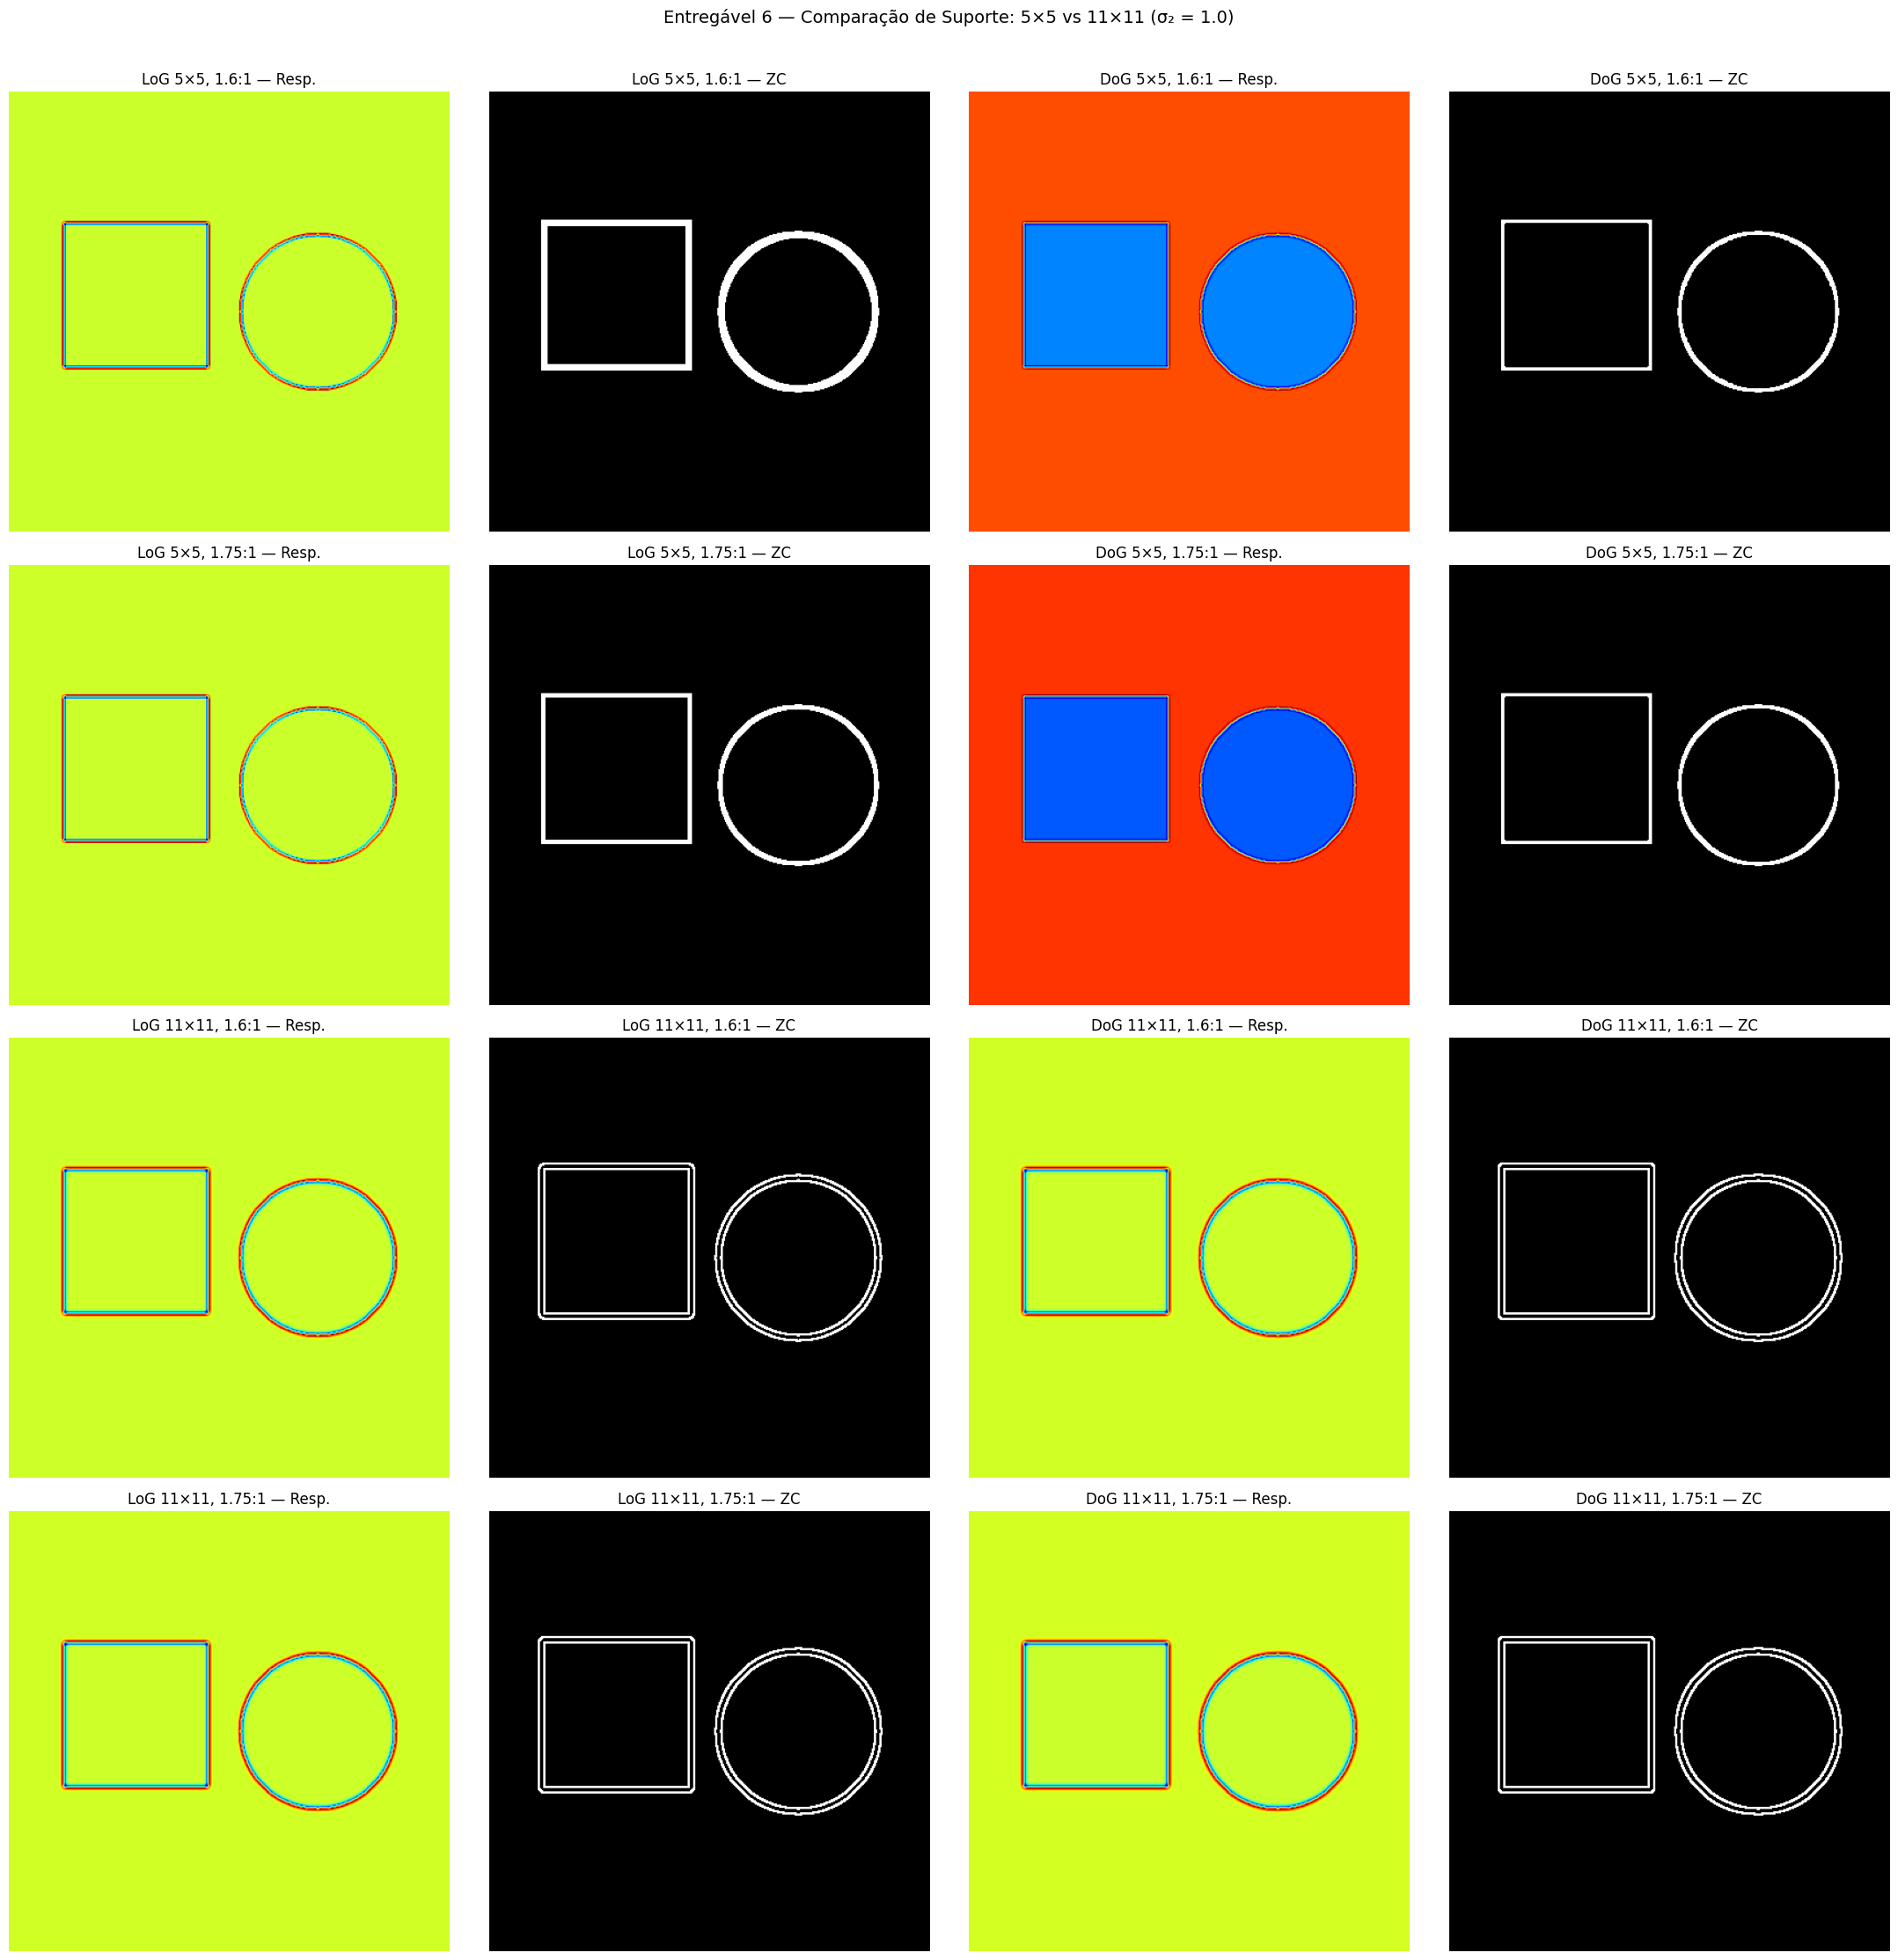


--- Estatísticas de Cruzamentos por Zero ---
  5×5,  1.6:1: LoG=6508, DoG=3540, coincidentes=3540
  5×5,  1.75:1: LoG=4412, DoG=3508, coincidentes=3508
  11×11, 1.6:1: LoG=4508, DoG=4508, coincidentes=4204
  11×11, 1.75:1: LoG=4508, DoG=4508, coincidentes=4316


In [12]:
# ===== Filtros 11x11 (k=5), mesmos sigma =====
k_11  = 5
s2_11 = 1.0

# Razão 1.6:1
s1_16_11     = 1.6 * s2_11
sigma_eq_16_11 = sigma_equivalente(s1_16_11, s2_11)
log_16_11    = LoG(k_11, sigma_eq_16_11)
dog_16_11    = DOG(k_11, s1_16_11, s2_11)
res_log_16_11 = cv2.filter2D(synthetic_img, cv2.CV_32F, log_16_11)
res_dog_16_11 = cv2.filter2D(synthetic_img, cv2.CV_32F, dog_16_11)
zc_log_16_11  = cruzamentos_por_zero(res_log_16_11)
zc_dog_16_11  = cruzamentos_por_zero(res_dog_16_11)

# Razão 1.75:1
s1_175_11      = 1.75 * s2_11
sigma_eq_175_11 = sigma_equivalente(s1_175_11, s2_11)
log_175_11     = LoG(k_11, sigma_eq_175_11)
dog_175_11     = DOG(k_11, s1_175_11, s2_11)
res_log_175_11  = cv2.filter2D(synthetic_img, cv2.CV_32F, log_175_11)
res_dog_175_11  = cv2.filter2D(synthetic_img, cv2.CV_32F, dog_175_11)
zc_log_175_11   = cruzamentos_por_zero(res_log_175_11)
zc_dog_175_11   = cruzamentos_por_zero(res_dog_175_11)

# ===== Visualização Comparativa =====
fig, axes = plt.subplots(4, 4, figsize=(22, 22))

configs = [
    ('5×5, 1.6:1',   res_log_16,     zc_log_16,     res_dog_16,     zc_dog_16),
    ('5×5, 1.75:1',  res_log_175,    zc_log_175,    res_dog_175,    zc_dog_175),
    ('11×11, 1.6:1', res_log_16_11,  zc_log_16_11,  res_dog_16_11,  zc_dog_16_11),
    ('11×11, 1.75:1',res_log_175_11, zc_log_175_11, res_dog_175_11, zc_dog_175_11),
]

for row, (label, r_log, z_log, r_dog, z_dog) in enumerate(configs):
    axes[row, 0].imshow(r_log, cmap='jet')
    axes[row, 0].set_title(f'LoG {label} — Resp.')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(z_log, cmap='gray')
    axes[row, 1].set_title(f'LoG {label} — ZC')
    axes[row, 1].axis('off')
    axes[row, 2].imshow(r_dog, cmap='jet')
    axes[row, 2].set_title(f'DoG {label} — Resp.')
    axes[row, 2].axis('off')
    axes[row, 3].imshow(z_dog, cmap='gray')
    axes[row, 3].set_title(f'DoG {label} — ZC')
    axes[row, 3].axis('off')

plt.suptitle('Entregável 6 — Comparação de Suporte: 5×5 vs 11×11 (σ₂ = 1.0)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\n--- Estatísticas de Cruzamentos por Zero ---')
for label, z_log, z_dog in [
    ('5×5,  1.6:1',   zc_log_16,     zc_dog_16),
    ('5×5,  1.75:1',  zc_log_175,    zc_dog_175),
    ('11×11, 1.6:1',  zc_log_16_11,  zc_dog_16_11),
    ('11×11, 1.75:1', zc_log_175_11, zc_dog_175_11),
]:
    match = np.sum((z_log > 0) & (z_dog > 0))
    print(f'  {label}: LoG={np.sum(z_log>0)}, DoG={np.sum(z_dog>0)}, coincidentes={match}')


#### Discussão — Efeito do Tamanho do Suporte

**Largura das bordas nas respostas:**  
Ao comparar os filtros 5×5 contra os filtros 11×11 (usando os mesmos $\sigma$), observa-se que as faixas de transição na resposta filtrada ficam mais definidas no filtro 11×11. Isso ocorre porque o suporte maior captura mais do "volume" da gaussiana (caudas), resultando numa aproximação mais fiel da função contínua.

**Espessura do cruzamento por zero:**  
Mesmo que a resposta do filtro 11×11 seja mais larga e espalhada, a linha detectada no mapa de cruzamentos por zero continua sendo uma linha fina com espessura de pixel unitária. Isso demonstra o poder matemático do operador: ele localiza precisamente o **centro** da transição, independentemente do quão suave seja a rampa da borda.

**Truncamento e arredondamento:**  
Para filtros 5×5 com $\sigma \approx 1{,}2$, o suporte captura apenas $6\sigma \approx 7{,}4$ — maior que 5 — o que significa truncamento significativo da gaussiana. Com 11×11, o truncamento é menor e os cruzamentos por zero do LoG e da DoG tendem a concordar melhor, pois os coeficientes representam mais fielmente as funções contínuas subjacentes.


### Entregável 7 — Marr-Hildreth pela Rota de Dois Passos

O algoritmo de Marr-Hildreth, pela rota de dois passos:

1. Suavizar a imagem com um *kernel* gaussiano $n \times n$ (Passo 1).
2. Aplicar o Laplaciano $3\times 3$ à imagem suavizada (Passo 2).
3. Localizar os cruzamentos por zero (Passo 3).

Usamos $\sigma = 1{,}5$ e $k = 4$ (suporte $9\times 9$, pois $6\sigma \approx 9$).


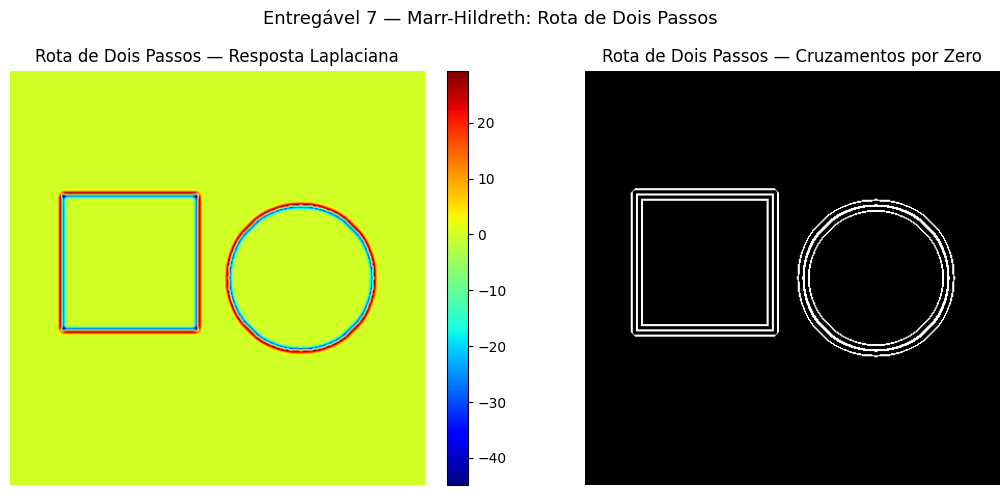

Bordas detectadas (Rota de Dois Passos): 5608 pixels


In [13]:
s_mh = 1.5
k_mh = 4  # suporte 9×9

resp_mh, bordas_mh = marr_hildreth(synthetic_img, k=k_mh, s=s_mh, limiar=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = axes[0].imshow(resp_mh, cmap='jet')
axes[0].set_title('Rota de Dois Passos — Resposta Laplaciana')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].axis('off')
axes[1].imshow(bordas_mh, cmap='gray')
axes[1].set_title('Rota de Dois Passos — Cruzamentos por Zero')
axes[1].axis('off')
plt.suptitle('Entregável 7 — Marr-Hildreth: Rota de Dois Passos', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Bordas detectadas (Rota de Dois Passos): {np.sum(bordas_mh > 0)} pixels')


### Entregável 8 — Comparação: Rota de Dois Passos vs LoG Direto

Comparamos a rota de dois passos com a convolução direta com o operador LoG amostrado, verificando empiricamente a equivalência da Equação (11) do roteiro:

$$g(x,y) = \nabla^2\!\big[G(x,y) \star f(x,y)\big] = \big[\nabla^2 G(x,y)\big] \star f(x,y)$$


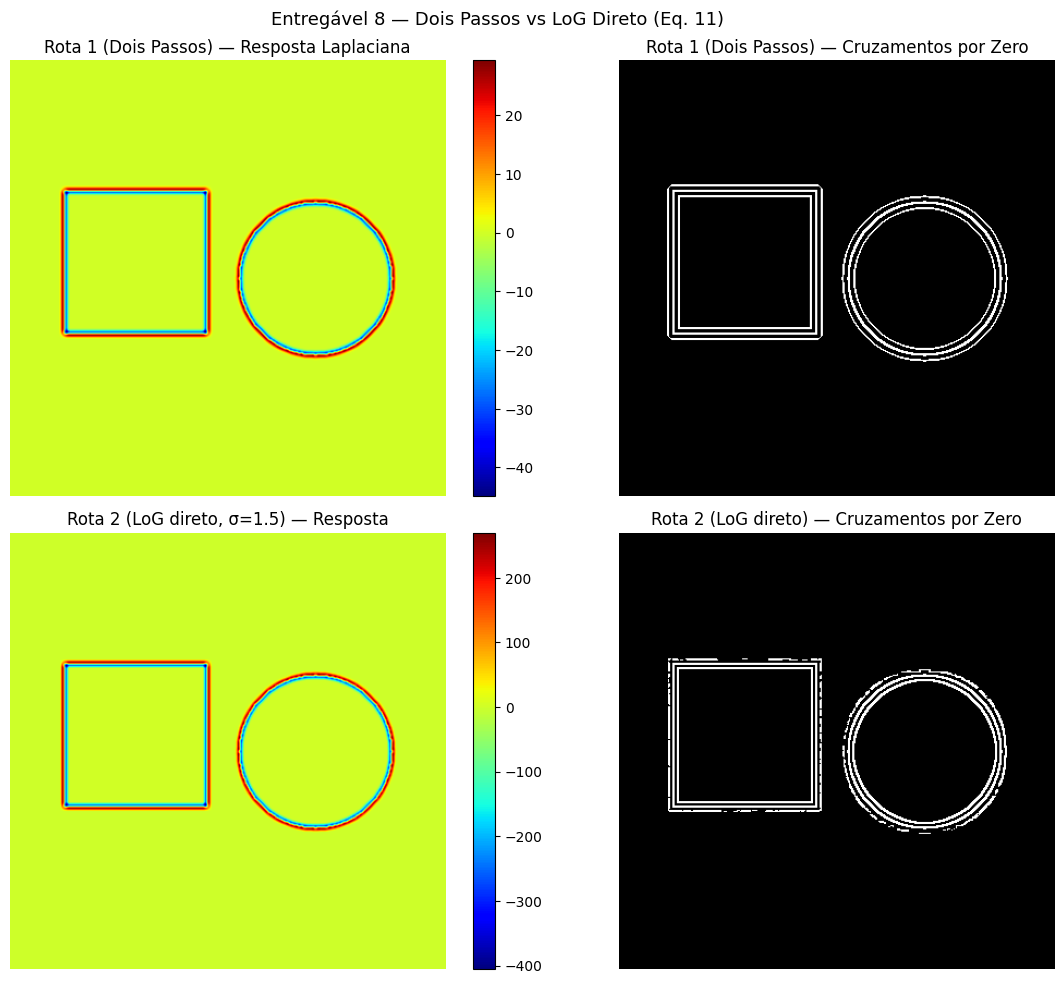

Bordas (Rota 1 — Dois Passos): 5608 pixels
Bordas (Rota 2 — LoG direto):  5879 pixels
Bordas coincidentes:            4091 pixels
Taxa de coincidência:           69.6%


In [14]:
log_direto = LoG(k_mh, s_mh)
res_log_direto = cv2.filter2D(synthetic_img.astype(float), cv2.CV_64F, log_direto)
bordas_log_direto = cruzamentos_por_zero(res_log_direto, limiar=0.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im1 = axes[0, 0].imshow(resp_mh, cmap='jet')
axes[0, 0].set_title('Rota 1 (Dois Passos) — Resposta Laplaciana')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)
axes[0, 0].axis('off')

axes[0, 1].imshow(bordas_mh, cmap='gray')
axes[0, 1].set_title('Rota 1 (Dois Passos) — Cruzamentos por Zero')
axes[0, 1].axis('off')

im2 = axes[1, 0].imshow(res_log_direto, cmap='jet')
axes[1, 0].set_title(f'Rota 2 (LoG direto, σ={s_mh}) — Resposta')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)
axes[1, 0].axis('off')

axes[1, 1].imshow(bordas_log_direto, cmap='gray')
axes[1, 1].set_title('Rota 2 (LoG direto) — Cruzamentos por Zero')
axes[1, 1].axis('off')

plt.suptitle('Entregável 8 — Dois Passos vs LoG Direto (Eq. 11)', fontsize=13)
plt.tight_layout()
plt.show()

match     = np.sum((bordas_mh > 0) & (bordas_log_direto > 0))
total_mh  = np.sum(bordas_mh > 0)
total_log = np.sum(bordas_log_direto > 0)
print(f'Bordas (Rota 1 — Dois Passos): {total_mh} pixels')
print(f'Bordas (Rota 2 — LoG direto):  {total_log} pixels')
print(f'Bordas coincidentes:            {match} pixels')
if max(total_mh, total_log) > 0:
    print(f'Taxa de coincidência:           {100*match/max(total_mh, total_log):.1f}%')


### Entregável 9 — Discussão Crítica

**1. Convenção de sinal:**  
A inversão de sinal ($M$ vs $-M$, LoG vs $-$LoG) não altera a posição dos cruzamentos por zero, apenas inverte quais regiões são positivas e quais são negativas. As bordas detectadas são geometricamente idênticas.

**2. Coincidência dos cruzamentos por zero LoG ↔ DoG:**  
A DoG se comporta como boa aproximação da LoG nos casos testados. As eventuais discrepâncias decorrem do arredondamento discreto dos coeficientes e do suporte finito. Para suportes maiores (11×11), a aproximação tende a melhorar pois mais da "cauda" da gaussiana é capturada.

**3. Tamanho do suporte:**  
Filtros maiores (11×11) capturam mais do volume da gaussiana, gerando respostas mais fiéis à função contínua. Os cruzamentos por zero continuam precisos e finos em ambos os casos. Filtros 5×5 sofrem de truncamento significativo quando $6\sigma$ excede o tamanho do suporte.

**4. Razão entre desvios padrão:**  
Razões menores ($1{,}6:1$) produzem filtros DoG mais seletivos em frequência (banda-passante mais estreita), enquanto razões maiores ($1{,}75:1$) ampliam a banda. A razão $1{,}6:1$ é a recomendação clássica de Marr e Hildreth.

**5. Arredondamento dos coeficientes e soma do filtro:**  
A normalização pela norma Euclidiana e o arredondamento para 3 casas decimais fazem com que a soma dos coeficientes não seja exatamente zero, embora próxima. Esse erro numérico tem impacto mínimo na detecção de bordas, que depende da posição dos cruzamentos por zero e não da amplitude da resposta.

**6. Equivalência suavizar-e-derivar ↔ LoG direto:**  
As duas rotas do algoritmo de Marr-Hildreth produzem os mesmos cruzamentos por zero, confirmando empiricamente a comutatividade da convolução com a diferenciação (Equação 11). As diferenças numéricas nas amplitudes são irrelevantes para a localização das bordas.

**7. A máscara inteira de Gonzalez & Woods:**  
A máscara $M$ de coeficientes inteiros **não** é uma amostragem direta da função LoG contínua, mas sim uma aproximação discreta compacta ajustada para uso prático. Seus coeficientes foram escolhidos para manter soma nula e simetria radial aproximada, capturando o comportamento essencial do LoG sem necessidade de ponto flutuante.
